In [26]:
import pandas as pd

# 1. Load main dataset
file_path = "/Users/pujithaattuluri/Desktop/UNCC fall 2025/Visual Analytics & storytelling/Big Idea group project/Fracture Care Analysis.xlsx"   # adjust path if needed
df = pd.read_excel(file_path, sheet_name="dashboard_full")

# 2. Quick peek
print(df.shape)
print(df.head())
print(df.dtypes)

# 3. Create key engineered columns

# Repeat fracture flag (A: prediction target)
df["Repeat_Fracture_Flag"] = (df["Fracture_Count"] >= 2).astype(int)

# Any fracture flag (in case we need it for filtering)
df["Any_Fracture_Flag"] = (df["Fracture_Count"] >= 1).astype(int)

# Clean up text columns (strip spaces, standardize case)
text_cols = ["Sex", "Race", "Fracture", "Hip_Fracture", "Wrist_Fracture",
             "Spine_Fracture", "Diagnosed", "On_Medication",
             "Care_Gap", "Bone_Status", "Undiagnosed_Osteo",
             "Parent_Osteoporosis", "Parent_Hip_Fracture"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 4. Basic NA check
print(df.isna().sum())


(4987, 19)
     SEQN  Age AgeGroup   Sex            Race Fracture Hip_Fracture  \
0  109274   68    60-69  Male     Other/Multi       No           No   
1  109282   76    70-79  Male           White      Yes           No   
2  109283   52    50-59  Male     Other/Multi       No           No   
3  109290   68    60-69  Fema           Black       No           No   
4  109292   58    50-59  Male  Other Hispanic       No           No   

  Wrist_Fracture Spine_Fracture  Fracture_Count Diagnosed On_Medication  \
0             No             No               0        No            No   
1            Yes            Yes               2        No            No   
2             No             No               0        No            No   
3             No             No               0        No            No   
4             No             No               0        No            No   

  Care_Gap    BMD    Tscore   Bone_Status Undiagnosed_Osteo  \
0       No  0.831 -0.727941        Normal       

In [27]:
import pandas as pd

# A. Overall Care Gap % (How many have a care gap)
overall_care_gap = df["Care_Gap"].value_counts(normalize=True) * 100

# B. Diagnosis gap (fracture patients who were NOT diagnosed with osteoporosis)
diagnosis_gap = df[df["Any_Fracture_Flag"] == 1]["Diagnosed"].value_counts(normalize=True) * 100

# C. Medication gap (osteoporosis/osteopenia patients NOT on medication)
med_gap = df[df["Bone_Status"].isin(["Osteopenia", "Osteoporosis"])]["On_Medication"].value_counts(normalize=True) * 100

overall_care_gap, diagnosis_gap, med_gap


(Care_Gap
 No     88.650491
 Yes    11.349509
 Name: proportion, dtype: float64,
 Diagnosed
 No     77.961433
 Yes    22.038567
 Name: proportion, dtype: float64,
 On_Medication
 No     91.367341
 Yes     8.632659
 Name: proportion, dtype: float64)

In [28]:
# Care Gap by age group
care_gap_age = df.groupby("AgeGroup")["Care_Gap"].value_counts(normalize=True).unstack().fillna(0) * 100

# Care Gap by sex
care_gap_sex = df.groupby("Sex")["Care_Gap"].value_counts(normalize=True).unstack().fillna(0) * 100

# Care Gap by race
care_gap_race = df.groupby("Race")["Care_Gap"].value_counts(normalize=True).unstack().fillna(0) * 100

care_gap_age, care_gap_sex, care_gap_race


(Care_Gap         No        Yes
 AgeGroup                      
 50-59     88.051118  11.948882
 60-69     88.316151  11.683849
 70-79     90.543260   9.456740
 80+       88.123167  11.876833,
 Care_Gap         No        Yes
 Sex                           
 Fema      90.919905   9.080095
 Male      86.328600  13.671400,
 Care_Gap                 No        Yes
 Race                                  
 Asian             95.283019   4.716981
 Black             91.522881   8.477119
 Mexican American  92.778993   7.221007
 Other Hispanic    88.757396  11.242604
 Other/Multi       82.653061  17.346939
 White             84.521385  15.478615)

In [29]:
care_gap_bone = df.groupby("Bone_Status")["Care_Gap"].value_counts(normalize=True).unstack().fillna(0) * 100
care_gap_bone


Care_Gap,No,Yes
Bone_Status,,
Normal,89.307049,10.692951
Osteopenia,87.592138,12.407862
Osteoporosis,89.020772,10.979228


In [30]:
repeat_vs_gap = df.groupby("Care_Gap")["Repeat_Fracture_Flag"].mean() * 100
repeat_vs_gap


Care_Gap
No      0.475006
Yes    10.954064
Name: Repeat_Fracture_Flag, dtype: float64

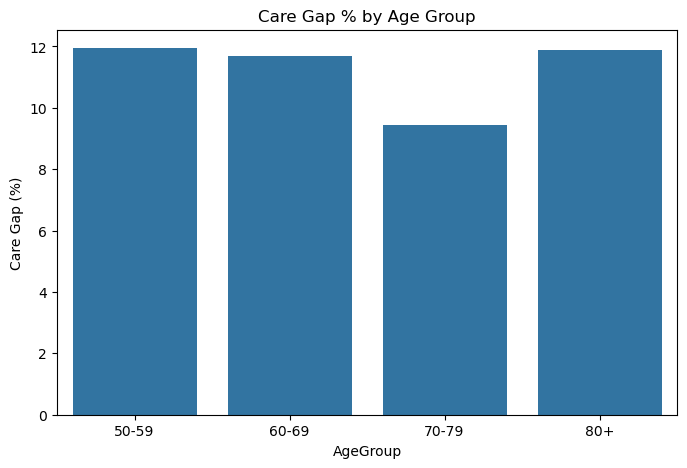

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    data=care_gap_age.reset_index(),
    x="AgeGroup", y="Yes"
)
plt.title("Care Gap % by Age Group")
plt.ylabel("Care Gap (%)")
plt.show()


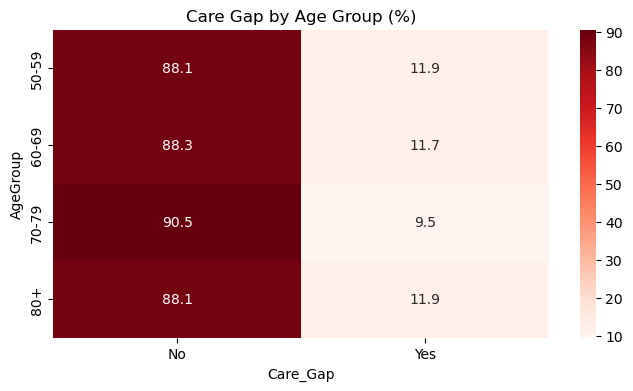

In [32]:
plt.figure(figsize=(8,4))
sns.heatmap(care_gap_age, annot=True, cmap="Reds", fmt=".1f")
plt.title("Care Gap by Age Group (%)")
plt.show()


/var/folders/yq/wll537d513xg9gvn1k81g41c0000gn/T/ipykernel_44752/773607374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


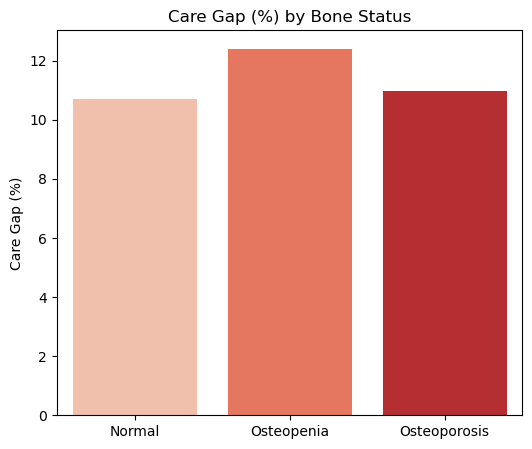

In [33]:
plt.figure(figsize=(6,5))
sns.barplot(
    data=care_gap_bone.reset_index(),
    x="Bone_Status",
    y="Yes",
    palette="Reds"
)
plt.title("Care Gap (%) by Bone Status")
plt.ylabel("Care Gap (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()


/var/folders/yq/wll537d513xg9gvn1k81g41c0000gn/T/ipykernel_44752/3556830468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


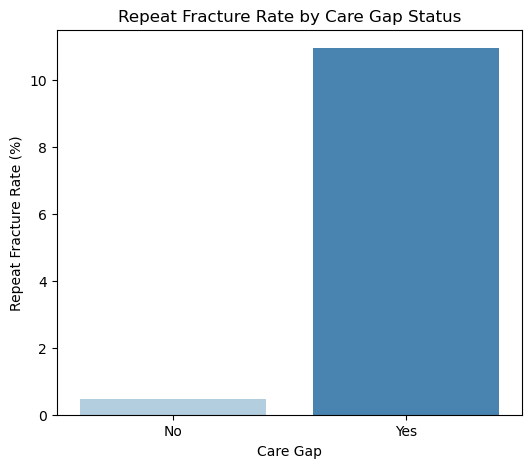

In [34]:
plt.figure(figsize=(6,5))
sns.barplot(
    x=repeat_vs_gap.index,
    y=repeat_vs_gap.values,
    palette="Blues"
)
plt.title("Repeat Fracture Rate by Care Gap Status")
plt.ylabel("Repeat Fracture Rate (%)")
plt.xlabel("Care Gap")
plt.show()


In [35]:
funnel_data = {
    "Total Patients": len(df),
    "Bone Loss (Osteopenia + Osteoporosis)": len(df[df["Bone_Status"].isin(["Osteopenia","Osteoporosis"])]),
    "Diagnosed": len(df[df["Diagnosed"] == "Yes"]),
    "On Medication": len(df[df["On_Medication"] == "Yes"])
}
funnel_data


{'Total Patients': 4987,
 'Bone Loss (Osteopenia + Osteoporosis)': 3313,
 'Diagnosed': 611,
 'On Medication': 312}

In [36]:
import numpy as np

# Target
y = df["Repeat_Fracture_Flag"]

# Quick class balance check
y.value_counts(normalize=True) * 100

# BASIC feature set
basic_features = [
    "Age",
    "Sex",
    "Race",
    "Bone_Status",
    "Diagnosed",
    "On_Medication",
    "Care_Gap",
]

# FULL feature set
full_features = [
    "Age",
    "AgeGroup",
    "Sex",
    "Race",
    "Bone_Status",
    "Diagnosed",
    "On_Medication",
    "Care_Gap",
    "Undiagnosed_Osteo",
    "Parent_Osteoporosis",
    "Parent_Hip_Fracture",
    "BMD",
    "Tscore",
]


# Subset
df_basic = df[basic_features].copy()
df_full  = df[full_features].copy()


In [37]:
# Categorical columns
cat_basic = df_basic.select_dtypes(include="object").columns.tolist()
cat_full  = df_full.select_dtypes(include="object").columns.tolist()

X_basic = pd.get_dummies(df_basic, columns=cat_basic, drop_first=True)
X_full  = pd.get_dummies(df_full,  columns=cat_full,  drop_first=True)

X_basic.shape, X_full.shape


((4987, 12), (4987, 20))

In [38]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)


In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score

# Pipeline: impute -> scale -> logistic
log_basic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced"))
])

log_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced"))
])

# Train
log_basic.fit(Xb_train, yb_train)
log_full.fit(Xf_train, yf_train)

# Evaluate
for name, model, X_tr, X_te, y_tr, y_te in [
    ("Basic", log_basic, Xb_train, Xb_test, yb_train, yb_test),
    ("Full",  log_full, Xf_train, Xf_test, yf_train, yf_test),
]:
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]
    print("=== Logistic Regression -", name, "===")
    print("ROC AUC:", roc_auc_score(y_te, y_proba).round(3))
    print(classification_report(y_te, y_pred))


=== Logistic Regression - Basic ===
ROC AUC: 0.947
              precision    recall  f1-score   support

           0       1.00      0.77      0.87       981
           1       0.07      1.00      0.13        17

    accuracy                           0.78       998
   macro avg       0.54      0.89      0.50       998
weighted avg       0.98      0.78      0.86       998

=== Logistic Regression - Full ===
ROC AUC: 0.938
              precision    recall  f1-score   support

           0       1.00      0.81      0.89       981
           1       0.08      1.00      0.15        17

    accuracy                           0.81       998
   macro avg       0.54      0.90      0.52       998
weighted avg       0.98      0.81      0.88       998



In [40]:
imputer = SimpleImputer(strategy="median")
Xf_train_imp = imputer.fit_transform(Xf_train)
Xf_test_imp  = imputer.transform(Xf_test)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf.fit(Xf_train, yf_train)

y_pred_rf = rf.predict(Xf_test)
y_proba_rf = rf.predict_proba(Xf_test)[:,1]

print("=== Random Forest - Full ===")
print("ROC AUC:", roc_auc_score(yf_test, y_proba_rf).round(3))
print(classification_report(yf_test, y_pred_rf))


=== Random Forest - Full ===
ROC AUC: 0.937
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       981
           1       0.25      0.35      0.29        17

    accuracy                           0.97       998
   macro avg       0.62      0.67      0.64       998
weighted avg       0.98      0.97      0.97       998



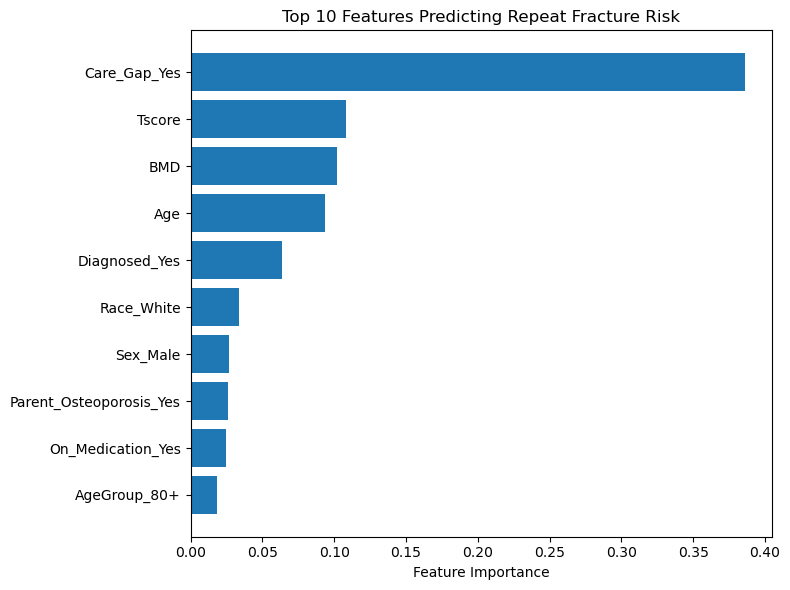

In [41]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # top 10

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices][::-1])
plt.yticks(range(len(indices)), X_full.columns[indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Features Predicting Repeat Fracture Risk")
plt.tight_layout()
plt.show()


In [42]:
cluster_features = [
    "Age",
    "Sex",
    "Race",
    "Bone_Status",
    "Diagnosed",
    "On_Medication",
    "Care_Gap",
    "Undiagnosed_Osteo",
    "Parent_Osteoporosis",
    "Parent_Hip_Fracture",
    "BMD",
    "Tscore"
]


In [43]:
clust_df = df[cluster_features].copy()

# One-hot encode categoricals
cat_cols = clust_df.select_dtypes(include="object").columns.tolist()
clust_df = pd.get_dummies(clust_df, columns=cat_cols, drop_first=True)

# Impute missing values
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy="median")
clust_df_imp = imp.fit_transform(clust_df)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
clust_scaled = scaler.fit_transform(clust_df_imp)

clust_scaled.shape


(4987, 17)

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
clust_pca = pca.fit_transform(clust_scaled)

pca_df = pd.DataFrame(clust_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = -1  # placeholder for later


In [45]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(clust_scaled)

pca_df["Cluster"] = clusters
df["Cluster"] = clusters   # attach back to original for profiling


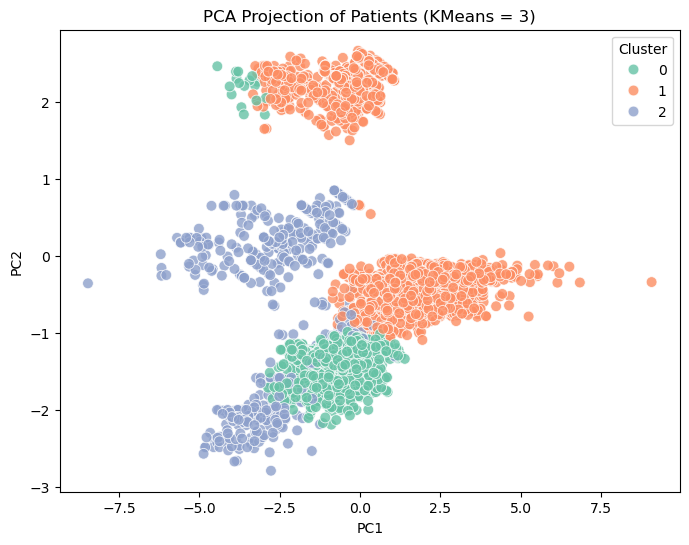

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="Cluster",
    palette="Set2",
    data=pca_df,
    s=60, alpha=0.8
)
plt.title("PCA Projection of Patients (KMeans = 3)")
plt.show()


In [50]:
cluster_profile = df.groupby("Cluster")[
    ["Age", "Tscore", "BMD"]
].mean()

cluster_profile


,Age,Tscore,BMD
Cluster,,,
0,65.333559,-1.649452,0.685477
1,64.054045,-0.285126,0.863496
2,71.172608,-1.913798,0.633000


In [48]:
cat_profile = df.groupby("Cluster")[
    ["Bone_Status", "Diagnosed", "On_Medication", "Care_Gap", "Race", "Sex"]
].agg(lambda x: x.value_counts().index[0])

cat_profile


,Bone_Status,Diagnosed,On_Medication,Care_Gap,Race,Sex
Cluster,,,,,,
0,Osteopenia,No,No,No,White,Male
1,Normal,No,No,No,White,Male
2,Osteoporosis,Yes,Yes,No,White,Fema


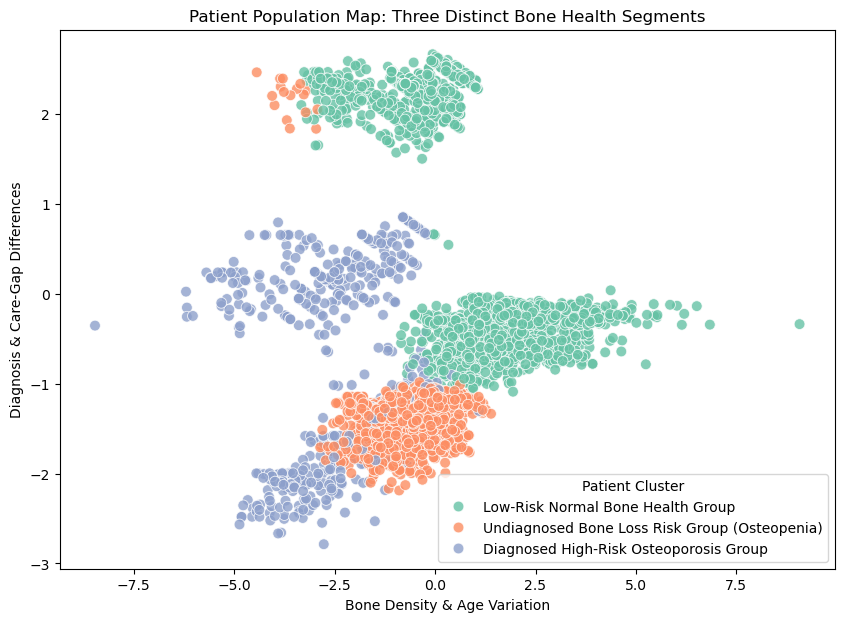

In [97]:
# Map numeric cluster labels to names
cluster_map = {
    0: "Undiagnosed Bone Loss Risk Group (Osteopenia)",
    1: "Low-Risk Normal Bone Health Group",
    2: "Diagnosed High-Risk Osteoporosis Group"
}

# Apply mapping to PCA dataframe and original df
pca_df["Cluster_Label"] = pca_df["Cluster"].map(cluster_map)
df["Cluster_Label"] = df["Cluster"].map(cluster_map)

plt.figure(figsize=(10,7))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster_Label",
    palette="Set2",
    data=pca_df,
    s=60,
    alpha=0.8
)
plt.xlabel("Bone Density & Age Variation")
plt.ylabel("Diagnosis & Care-Gap Differences")
plt.title("Patient Population Map: Three Distinct Bone Health Segments")
plt.legend(title="Patient Cluster")
plt.show()


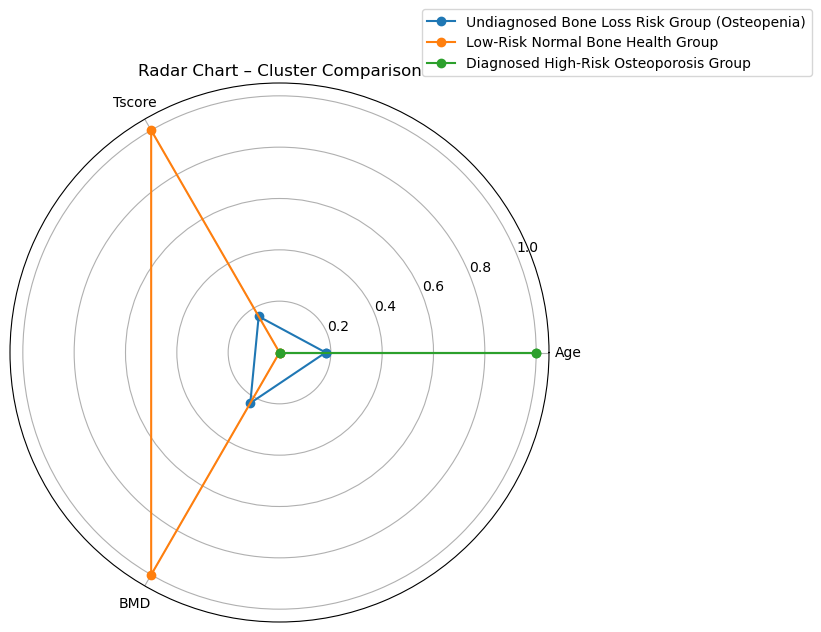

In [52]:
import numpy as np

# Features for radar chart (continuous only)
radar_cols = ["Age", "Tscore", "BMD"]

radar_data = df.groupby("Cluster")[radar_cols].mean()

# Normalize 0–1 for radar chart
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

# Radar chart
labels = radar_cols
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
for i in range(3):
    values = radar_norm.iloc[i].tolist()
    values += values[:1]
    plt.polar(angles, values, label=cluster_map[i], marker='o')

plt.xticks(angles[:-1], labels)
plt.title("Radar Chart – Cluster Comparison")
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15))
plt.show()


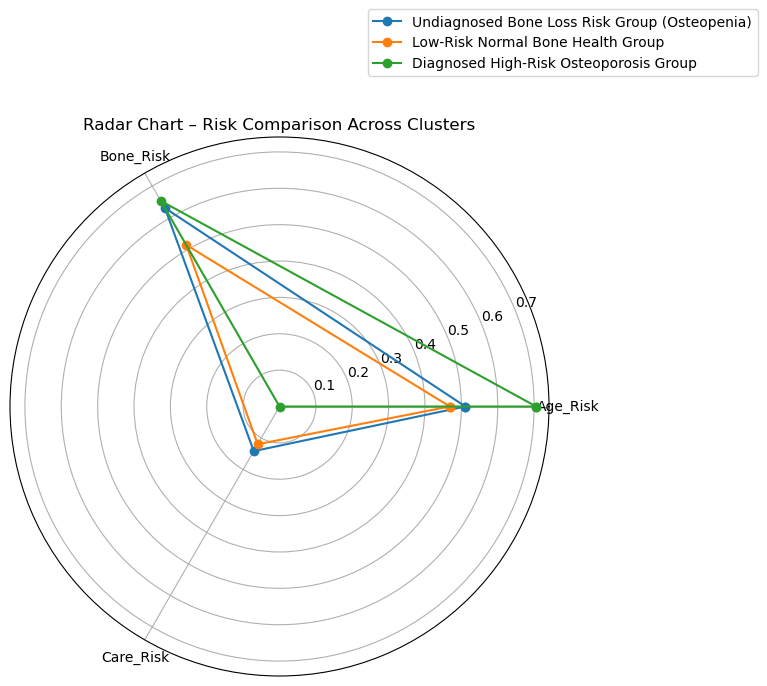

In [54]:
# Create risk-normalized features for radar

radar_df = df.copy()

# 1. Age Risk
radar_df["Age_Risk"] = (radar_df["Age"] - radar_df["Age"].min()) / (radar_df["Age"].max() - radar_df["Age"].min())

# 2. Bone Density Risk (reverse T-score)
radar_df["Bone_Risk"] = (-radar_df["Tscore"] - (-radar_df["Tscore"]).min()) / ((-radar_df["Tscore"]).max() - (-radar_df["Tscore"]).min())

# 3. Care Gap Risk
radar_df["Care_Risk"] = radar_df["Care_Gap"].apply(lambda x: 1 if x=="Yes" else 0)

# Group averages
risk_radar = radar_df.groupby("Cluster")[["Age_Risk", "Bone_Risk", "Care_Risk"]].mean()
risk_radar


labels = ["Age_Risk", "Bone_Risk", "Care_Risk"]
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
for i in range(3):
    values = risk_radar.iloc[i].tolist()
    values += values[:1]
    plt.polar(angles, values, label=cluster_map[i], marker='o')

plt.xticks(angles[:-1], labels)
plt.title("Radar Chart – Risk Comparison Across Clusters")
plt.legend(loc='lower right', bbox_to_anchor=(1.4, 1.1))
plt.show()


In [58]:
import pandas as pd

clinic_path = "/Users/pujithaattuluri/Desktop/UNCC fall 2025/Visual Analytics & storytelling/Big Idea group project/Utility of a bone health clinic in bridging the osteoporosis care gap.xlsx"
xls = pd.ExcelFile(clinic_path)
print(xls.sheet_names)

# Read with header row = 1 (0-based index)
clinic_orders = pd.read_excel(clinic_path, sheet_name="Orders", header=1)

clinic_orders.head()
clinic_orders.dtypes 



['Orders', 'Spec by Med', 'Prov in Spec 2', 'Age', 'Patient AgeSex by Spec']


Marital status                       object
Gender                               object
race                                 object
Ethnicity                            object
Admit Date                   datetime64[ns]
Encounter type                       object
Age - at visit                        int64
Order Height                        float64
Order Weight                         object
Column1                             float64
Med Service                          object
Order Catalog Mnemonic               object
Ordered As Mnemonic                  object
Order Date & Time            datetime64[ns]
Order Status                         object
Column2                             float64
Action provider position             object
 Derived Provider Service            object
Column4                             float64
Action personnel position            object
Duration                            float64
Duration Unit                        object
Frequency                       

In [65]:
clinic = clinic_orders.rename(columns={
    "Gender": "Sex",
    "Age - at visit": "Age",
    " Derived Provider Service": "Specialty",
    "Admit Date": "Admit_Date",
    "Order Status": "Order_Status"
})

clinic[["Sex", "Age", "Specialty", "Admit_Date", "Order_Status"]].head()


,Sex,Age,Specialty,Admit_Date,Order_Status
0,Female,82,Orthopaedic Surgery,2016-04-25 12:06:11,DISCONTINUED
1,Female,71,Internal Medicine,2018-08-16 11:16:51,Completed
2,Male,64,Dermatology,2020-01-22 09:28:18,Ordered
3,Female,56,Orthopaedic Surgery,2017-11-29 13:17:37,Completed
4,Female,58,Orthopaedic Surgery,2019-12-27 11:03:56,DISCONTINUED


In [66]:
clinic.columns.tolist()


['Marital status',
 'Sex',
 'race',
 'Ethnicity',
 'Admit_Date',
 'Encounter type',
 'Age',
 'Order Height',
 'Order Weight',
 'Column1',
 'Med Service',
 'Order Catalog Mnemonic',
 'Ordered As Mnemonic',
 'Order Date & Time',
 'Order_Status',
 'Column2',
 'Action provider position',
 'Specialty',
 'Column4',
 'Action personnel position',
 'Duration',
 'Duration Unit',
 'Frequency',
 'Column3']

In [61]:
# General population summary (df is your main fracture dataset)
gen_summary = pd.DataFrame({
    "population": ["General"],
    "n_patients": [len(df)],
    "mean_age": [df["Age"].mean()],
    "pct_female": [(df["Sex"] == "Female").mean() * 100]
})

# Clinic population summary
clinic_summary = pd.DataFrame({
    "population": ["Clinic"],
    "n_patients": [len(clinic)],
    "mean_age": [clinic["Age"].astype(float).mean()],
    "pct_female": [(clinic["Sex"] == "Female").mean() * 100]
})

pop_compare = pd.concat([gen_summary, clinic_summary], ignore_index=True)
pop_compare


,population,n_patients,mean_age,pct_female
0,General,4987,65.193303,0.000000
1,Clinic,10758,68.213516,87.776538


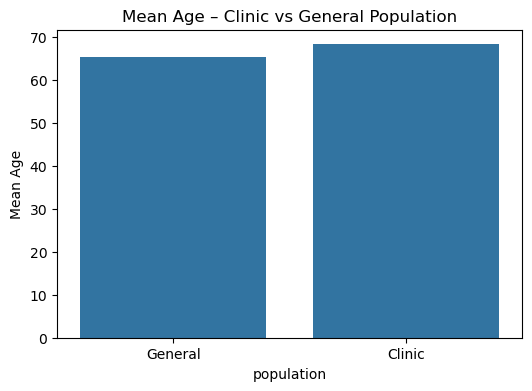

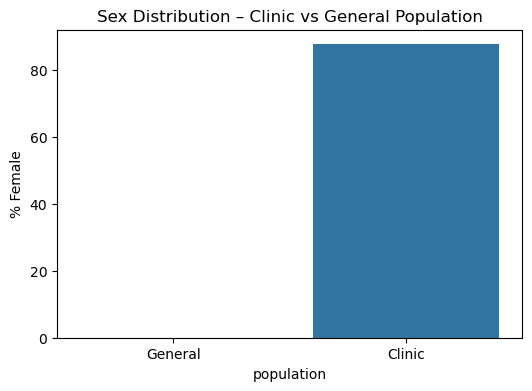

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(data=pop_compare, x="population", y="mean_age")
plt.ylabel("Mean Age")
plt.title("Mean Age – Clinic vs General Population")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=pop_compare, x="population", y="pct_female")
plt.ylabel("% Female")
plt.title("Sex Distribution – Clinic vs General Population")
plt.show()


In [63]:
clinic.columns.tolist()


['Marital status',
 'Sex',
 'race',
 'Ethnicity',
 'Admit_Date',
 'Encounter type',
 'Age',
 'Order Height',
 'Order Weight',
 'Column1',
 'Med Service',
 'Order Catalog Mnemonic',
 'Ordered As Mnemonic',
 'Order Date & Time',
 'Order_Status',
 'Column2',
 'Action provider position',
 'Specialty',
 'Column4',
 'Action personnel position',
 'Duration',
 'Duration Unit',
 'Frequency',
 'Column3']

In [64]:
[c for c in clinic.columns if "BMD" in c or "T" in c or "DXA" in c or "diag" in c.lower() or "rx" in c.lower()]


['Order Date & Time']

In [70]:
spec_by_med = pd.read_excel(clinic_path, sheet_name="Spec by Med", header=3)
spec_by_med.columns.tolist()
spec_by_med.head()


,Row Labels,abaloparatide,alendronate,denosumab,ibandronate,raloxifene,risedronate,romosozumab,teriparatide,zoledronic acid,Grand Total
0,Allergy Immunoligy,NaN,7.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,9
1,Cardiology,NaN,26.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,30
2,Colorectal Surgery,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,Dermatology,NaN,88.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,89
4,Endocrinology,9.0,350.0,39.0,10.0,12.0,44.0,NaN,57.0,3.0,524


In [73]:
age_tab = pd.read_excel(clinic_path, sheet_name="Age", header=1)
age_tab.columns.tolist()
age_tab.head()


,Row Labels,Allergy Immunoligy,Cardiology,Colorectal Surgery,Dermatology,Endocrinology,Endoscopy,Family Medicine,Gastroenterology,Geriatrics,...,Radiation Oncology,Radiology/Intervention,Rehab,Rheumatology,Sports Medicine,Surgery Oncology,Trauma Surgery,Urology,Vascular Surgery,Grand Total
0,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
2,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
3,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,6
4,22,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,10


In [75]:
age_sex_tab = pd.read_excel(clinic_path, sheet_name="Patient AgeSex by Spec", header=4)
age_sex_tab.columns.tolist()
age_sex_tab.head()


,Row Labels,Percent of Specialty,Order Count,Percent of Specialty.1,Order Count.1
0,Allergy Immunoligy,0.888889,8.0,0.111111,1.0
1,Cardiology,0.533333,16.0,0.466667,14.0
2,Colorectal Surgery,1.000000,1.0,0.000000,NaN
3,Dermatology,0.730337,65.0,0.269663,24.0
4,Endocrinology,0.874046,458.0,0.125954,66.0


In [82]:
referrals_by_spec = (
    clinic["Specialty"]
    .value_counts()
    .reset_index()
)

referrals_by_spec.columns = ["Specialty", "Referral_Count"]

referrals_by_spec.head()


,Specialty,Referral_Count
0,Family Medicine,3867
1,Orthopaedic Surgery,3714
2,Internal Medicine,1216
3,Rheumatology,751
4,Endocrinology,524


In [83]:
order_status_by_spec = (
    clinic.groupby("Specialty")["Order_Status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
)

order_status_by_spec = order_status_by_spec.rename_axis(None, axis=1)
order_status_by_spec.head()


,Canceled,Completed,DISCONTINUED,Deleted,Ordered,Suspended
Specialty,,,,,,
Allergy Immunoligy,0.0,44.444444,22.222222,0.000000,33.333333,0.00000
Cardiology,0.0,56.666667,26.666667,0.000000,16.666667,0.00000
Colorectal Surgery,0.0,100.000000,0.000000,0.000000,0.000000,0.00000
Dermatology,0.0,39.325843,17.977528,1.123596,41.573034,0.00000
Endocrinology,0.0,52.290076,24.045802,0.954198,22.519084,0.19084


In [84]:
spec_by_med = pd.read_excel(clinic_path, sheet_name="Spec by Med", header=3)
spec_treatments = spec_by_med.rename(columns={"Row Labels": "Specialty"})
spec_treatments = spec_treatments[["Specialty", "Grand Total"]]
spec_treatments.head()


,Specialty,Grand Total
0,Allergy Immunoligy,9
1,Cardiology,30
2,Colorectal Surgery,1
3,Dermatology,89
4,Endocrinology,524


In [85]:
spec_analysis = (
    referrals_by_spec
    .merge(spec_treatments, on="Specialty", how="left")
    .merge(order_status_by_spec, on="Specialty", how="left")
    .fillna(0)
)

spec_analysis.head()


,Specialty,Referral_Count,Grand Total,Canceled,Completed,DISCONTINUED,Deleted,Ordered,Suspended
0,Family Medicine,3867,3867,0.02586,57.822601,20.610292,0.387898,20.998190,0.155159
1,Orthopaedic Surgery,3714,3714,0.00000,18.228325,51.669359,1.777060,28.325256,0.000000
2,Internal Medicine,1216,1216,0.00000,55.098684,25.822368,0.246711,18.750000,0.082237
3,Rheumatology,751,751,0.00000,59.786951,19.174434,0.665779,20.372836,0.000000
4,Endocrinology,524,524,0.00000,52.290076,24.045802,0.954198,22.519084,0.190840


In [81]:
referrals_by_spec.columns

Index(['Referral_Count', 'count'], dtype='object')

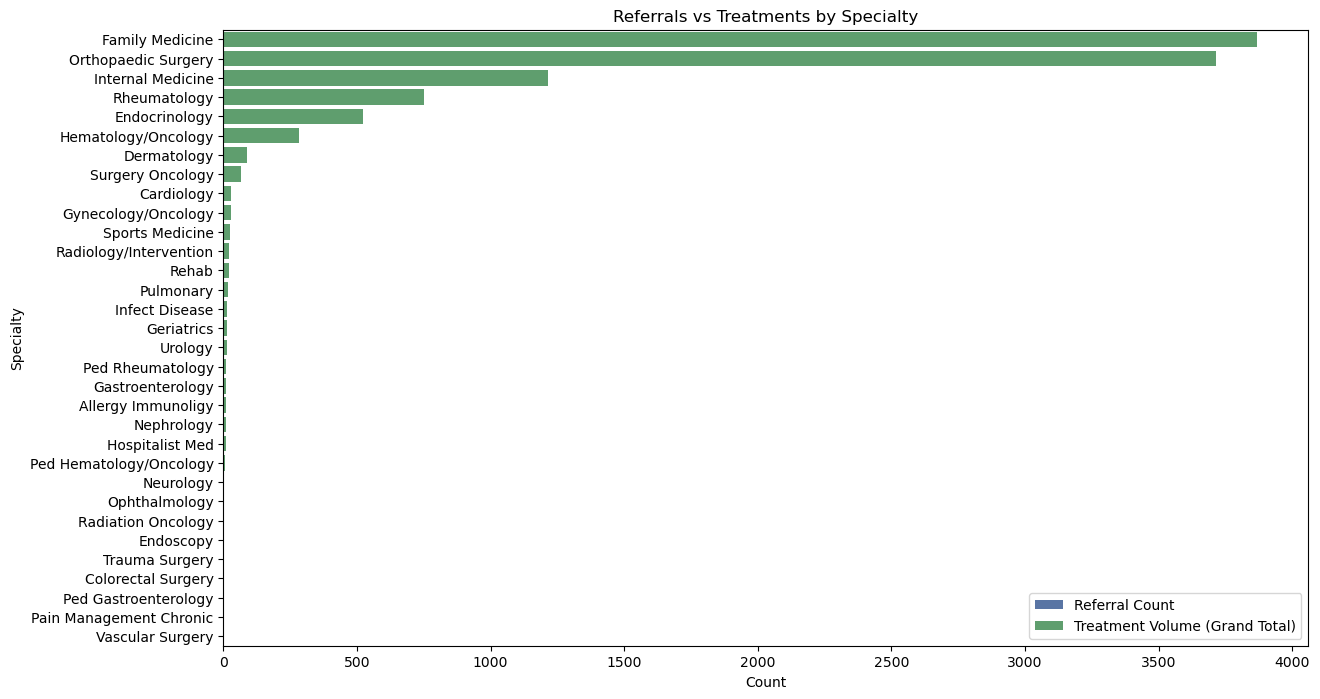

In [87]:
plt.figure(figsize=(14,8))

spec_plot = spec_analysis.sort_values("Referral_Count", ascending=False)

sns.barplot(
    data=spec_plot,
    x="Referral_Count",
    y="Specialty",
    color="#4C72B0",
    label="Referral Count"
)

sns.barplot(
    data=spec_plot,
    x="Grand Total",
    y="Specialty",
    color="#55A868",
    label="Treatment Volume (Grand Total)"
)

plt.xlabel("Count")
plt.ylabel("Specialty")
plt.title("Referrals vs Treatments by Specialty")
plt.legend(loc="lower right")
plt.show()


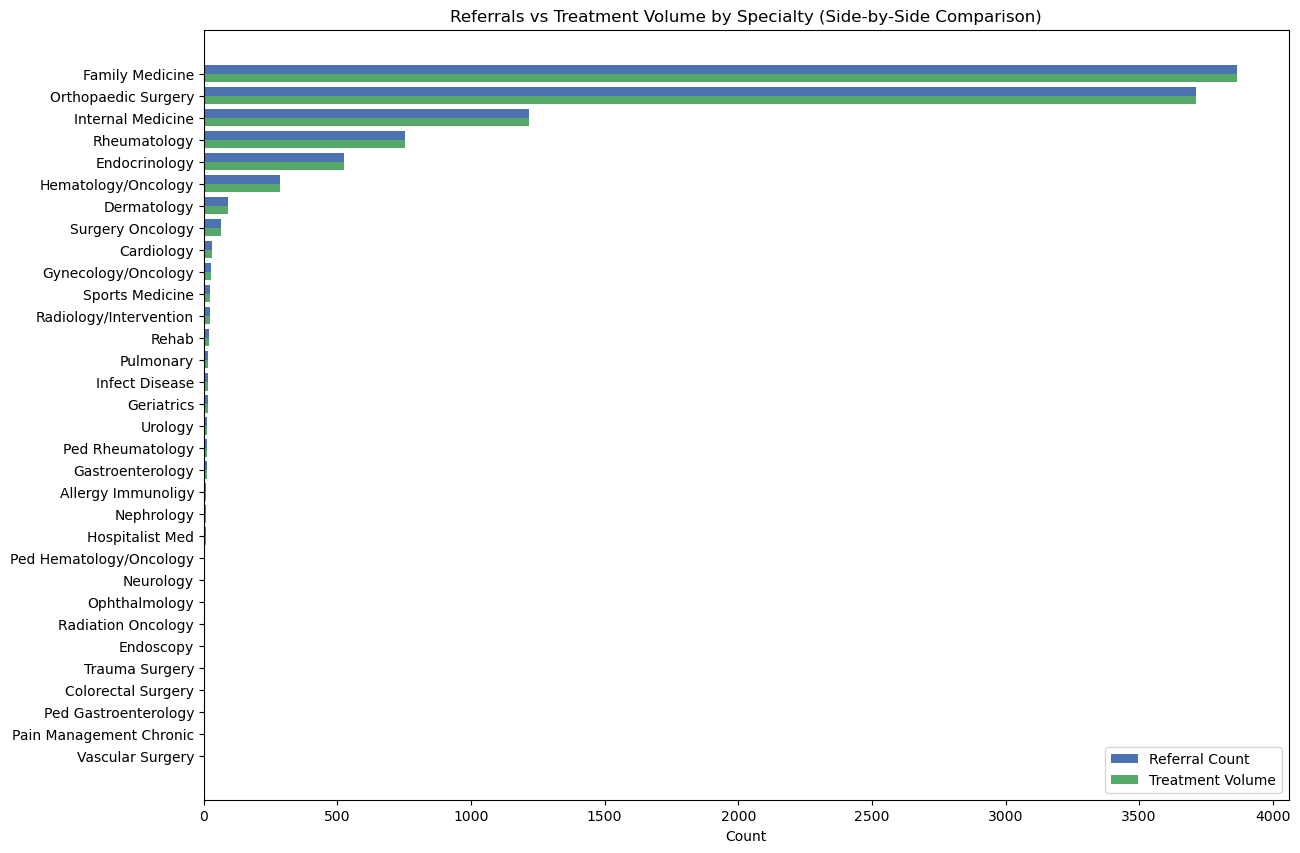

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data
spec_plot = spec_analysis.sort_values("Referral_Count", ascending=False)

# Number of specialties
y = np.arange(len(spec_plot))

# Bar height
h = 0.4  

plt.figure(figsize=(14,10))

plt.barh(y - h/2, spec_plot["Referral_Count"], height=h, label="Referral Count", color="#4C72B0")
plt.barh(y + h/2, spec_plot["Grand Total"], height=h, label="Treatment Volume", color="#55A868")

plt.yticks(y, spec_plot["Specialty"])
plt.xlabel("Count")
plt.title("Referrals vs Treatment Volume by Specialty (Side-by-Side Comparison)")
plt.legend(loc="lower right")

plt.gca().invert_yaxis()  # Highest at top
plt.show()


In [91]:
top_specs = [
    "Family Medicine", "Orthopaedic Surgery", "Internal Medicine",
    "Rheumatology", "Endocrinology", "Hematology/Oncology"
]

spec_top = spec_analysis[spec_analysis["Specialty"].isin(top_specs)]


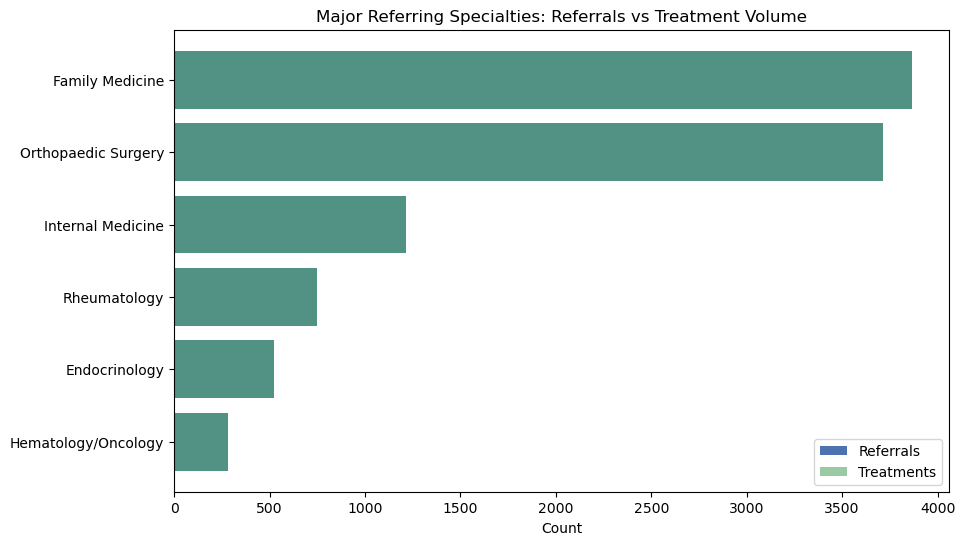

In [92]:
spec_top_plot = spec_top.sort_values("Referral_Count", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(spec_top_plot["Specialty"], spec_top_plot["Referral_Count"], label="Referrals", color="#4C72B0")
plt.barh(spec_top_plot["Specialty"], spec_top_plot["Grand Total"], alpha=0.6, label="Treatments", color="#55A868")
plt.title("Major Referring Specialties: Referrals vs Treatment Volume")
plt.xlabel("Count")
plt.legend()
plt.show()


/var/folders/yq/wll537d513xg9gvn1k81g41c0000gn/T/ipykernel_44752/489395560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


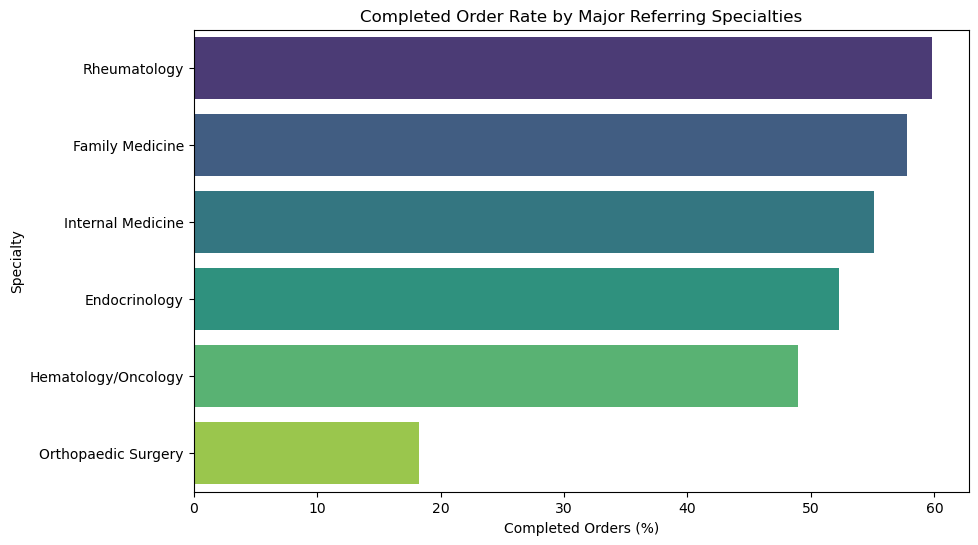

In [93]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=spec_top.sort_values("Completed", ascending=False),
    x="Completed", y="Specialty", palette="viridis"
)
plt.title("Completed Order Rate by Major Referring Specialties")
plt.xlabel("Completed Orders (%)")
plt.ylabel("Specialty")
plt.show()


/var/folders/yq/wll537d513xg9gvn1k81g41c0000gn/T/ipykernel_44752/2519230468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


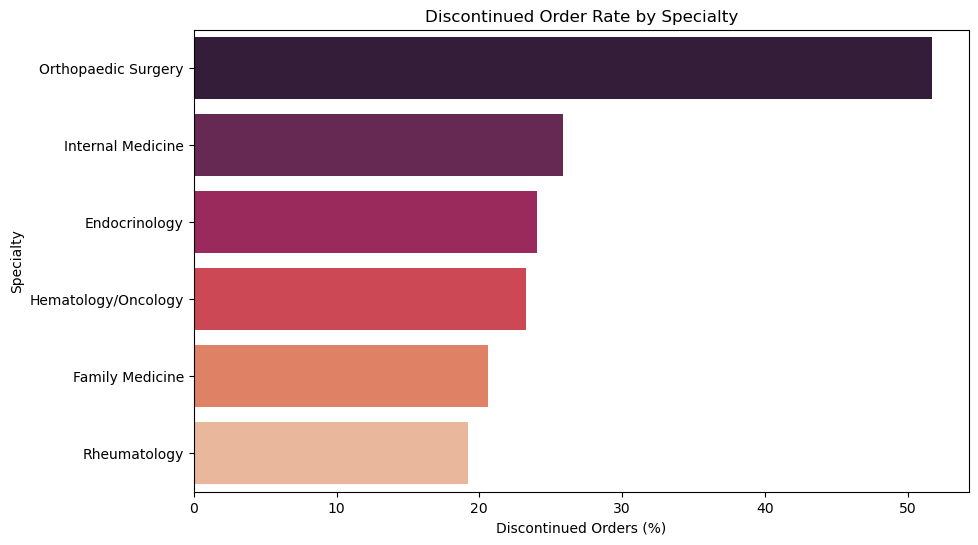

In [94]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=spec_top.sort_values("DISCONTINUED", ascending=False),
    x="DISCONTINUED", y="Specialty", palette="rocket"
)
plt.title("Discontinued Order Rate by Specialty")
plt.xlabel("Discontinued Orders (%)")
plt.ylabel("Specialty")
plt.show()


/var/folders/yq/wll537d513xg9gvn1k81g41c0000gn/T/ipykernel_44752/2802366386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


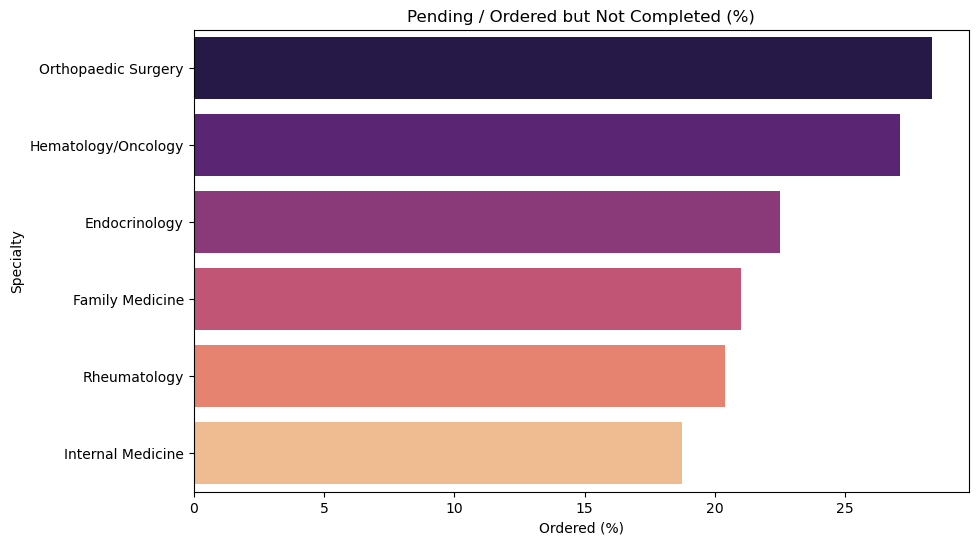

In [95]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=spec_top.sort_values("Ordered", ascending=False),
    x="Ordered", y="Specialty", palette="magma"
)
plt.title("Pending / Ordered but Not Completed (%)")
plt.xlabel("Ordered (%)")
plt.ylabel("Specialty")
plt.show()


Our analysis reveals that Orthopaedic Surgery — the specialty that treats fractures — has both the lowest completion rate (18%) and the highest discontinuation rate (55%) for DXA and osteoporosis-related orders. In contrast, specialties involved in long-term bone health management (Rheumatology, Endocrinology, Family Medicine) maintain far higher completion rates and far lower discontinuation. This confirms a critical care gap immediately following the fracture event, highlighting the need for automated referrals, standardized pathways, and dedicated bone health clinics to ensure timely evaluation and secondary fracture prevention.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Compute key clinical inputs from the data
# -----------------------------
# Make sure Care_Gap is 'Yes' / 'No' and Repeat_Fracture_Flag is 0/1
df['Care_Gap'] = df['Care_Gap'].astype(str)
df['Repeat_Fracture_Flag'] = df['Repeat_Fracture_Flag'].astype(int)

# Overall repeat-fracture rate
overall_repeat_rate = df['Repeat_Fracture_Flag'].mean()

# Repeat-fracture rate by care gap status
repeat_by_gap = (
    df.groupby('Care_Gap')['Repeat_Fracture_Flag']
      .mean()
      .rename({'No': 'No_Gap', 'Yes': 'Gap'})
)

rate_no_gap = repeat_by_gap.get('No', repeat_by_gap.get('No_Gap', 0))
rate_gap    = repeat_by_gap.get('Yes', repeat_by_gap.get('Gap', 0))

n_total = len(df)
n_gap   = (df['Care_Gap'] == 'Yes').sum()

print("Overall repeat fracture rate:     {:.2%}".format(overall_repeat_rate))
print("Repeat rate with NO care gap:     {:.2%}".format(rate_no_gap))
print("Repeat rate WITH a care gap:      {:.2%}".format(rate_gap))
print("Patients with a care gap (N_gap):", n_gap)

# -----------------------------
# 2. Scenario assumptions
# -----------------------------
# % of care-gap patients we manage to refer / close the gap
adoption_levels = [0.25, 0.50, 0.75]    # 25%, 50%, 75%
scenario_names  = ["25% Referrals", "50% Referrals", "75% Referrals"]

# Economic assumption 
COST_PER_REPEAT_FRACTURE = 30000  # USD per repeat fracture (example)

rows = []
for name, adoption in zip(scenario_names, adoption_levels):
    # Number of care-gap patients who get successfully referred in this scenario
    moved_patients = adoption * n_gap
    
    # For those moved patients, risk drops from 'gap' rate to 'no_gap' rate
    prevented_repeats = moved_patients * (rate_gap - rate_no_gap)
    
    # Dollar savings
    savings = prevented_repeats * COST_PER_REPEAT_FRACTURE
    
    rows.append({
        "Scenario": name,
        "Adoption_Rate": adoption,
        "Moved_Patients": moved_patients,
        "Prevented_Repeats": prevented_repeats,
        "Savings_USD": savings
    })

proj_df = pd.DataFrame(rows)
proj_df


Overall repeat fracture rate:     1.66%
Repeat rate with NO care gap:     0.48%
Repeat rate WITH a care gap:      10.95%
Patients with a care gap (N_gap): 566


,Scenario,Adoption_Rate,Moved_Patients,Prevented_Repeats,Savings_USD
0,25% Referrals,0.25,141.5,14.827867,4.448360e+05
1,50% Referrals,0.50,283.0,29.655734,8.896720e+05
2,75% Referrals,0.75,424.5,44.483601,1.334508e+06


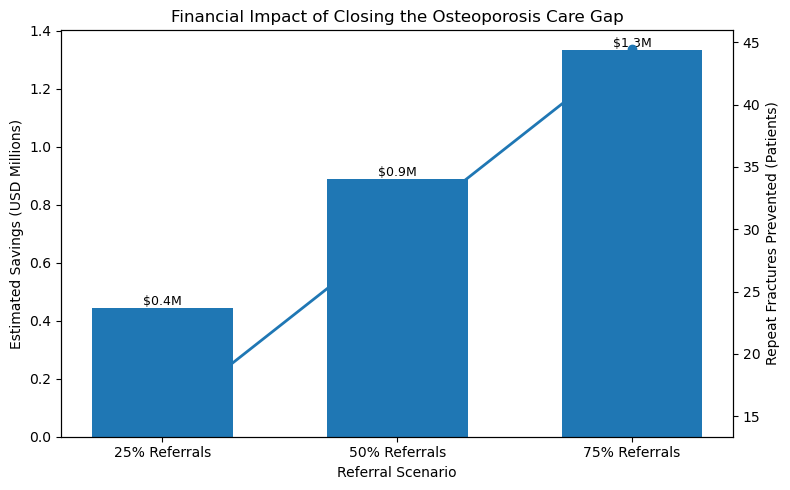

In [99]:
# -----------------------------
# 3. Financial projection plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(proj_df))

# Bar chart for cost savings (convert to millions for readability)
savings_millions = proj_df["Savings_USD"] / 1_000_000
bars = ax1.bar(x, savings_millions, width=0.6)
ax1.set_ylabel("Estimated Savings (USD Millions)")
ax1.set_xlabel("Referral Scenario")
ax1.set_xticks(x)
ax1.set_xticklabels(proj_df["Scenario"], rotation=0)
ax1.set_title("Financial Impact of Closing the Osteoporosis Care Gap")

# Secondary axis: number of prevented repeat fractures
ax2 = ax1.twinx()
ax2.plot(x, proj_df["Prevented_Repeats"], marker="o", linewidth=2)
ax2.set_ylabel("Repeat Fractures Prevented (Patients)")

# Add value labels on top of bars
for bar, val in zip(bars, savings_millions):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        height,
        f"${val:.1f}M",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()


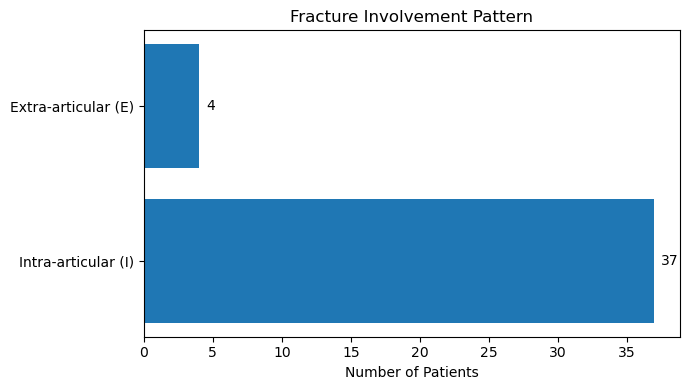

In [100]:
import matplotlib.pyplot as plt

# Data from your table
categories = ["Intra-articular (I)", "Extra-articular (E)"]
counts = [37, 4]

plt.figure(figsize=(7, 4))
plt.barh(categories, counts)

# Labels and title
plt.xlabel("Number of Patients")
plt.title("Fracture Involvement Pattern")

# Show values on the bars
for index, value in enumerate(counts):
    plt.text(value + 0.5, index, str(value), va='center')

plt.tight_layout()
plt.show()


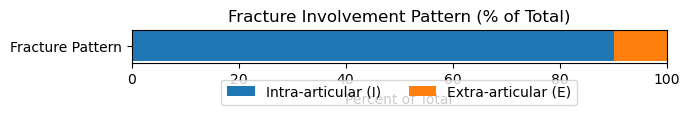

In [101]:
import matplotlib.pyplot as plt

categories = ["Intra-articular (I)", "Extra-articular (E)"]
percentages = [90.24, 9.76]

plt.figure(figsize=(7, 1.5))
plt.barh(["Fracture Pattern"], sum(percentages), color="white")

# Draw stacked bars
plt.barh(["Fracture Pattern"], percentages[0], label="Intra-articular (I)")
plt.barh(["Fracture Pattern"], percentages[1], left=percentages[0], label="Extra-articular (E)")

plt.title("Fracture Involvement Pattern (% of Total)")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.xlim(0, 100)
plt.xlabel("Percent of Total")
plt.tight_layout()
plt.show()


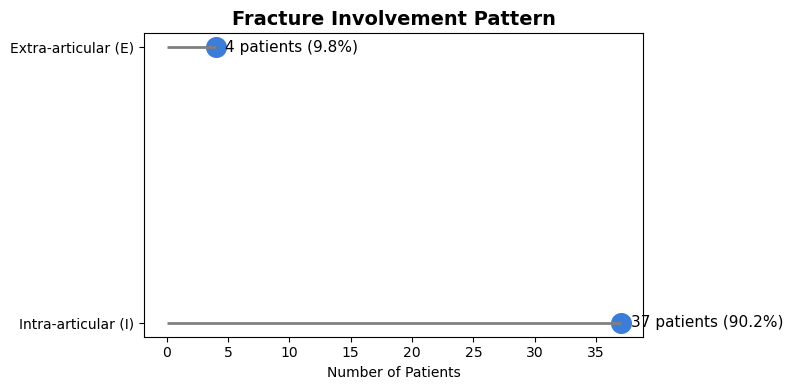

In [102]:
import matplotlib.pyplot as plt

categories = ["Intra-articular (I)", "Extra-articular (E)"]
counts = [37, 4]

plt.figure(figsize=(8,4))

# Draw stems
plt.hlines(y=categories, xmin=0, xmax=counts, color="gray", linewidth=2)

# Draw circles
plt.scatter(counts, categories, s=200, color="#3b7dd8")

# Add labels
for index, value in enumerate(counts):
    plt.text(value + 0.8, categories[index], f"{value} patients ({value/41*100:.1f}%)",
             va='center', fontsize=11)

plt.title("Fracture Involvement Pattern", fontsize=14, weight='bold')
plt.xlabel("Number of Patients")
plt.tight_layout()
plt.show()


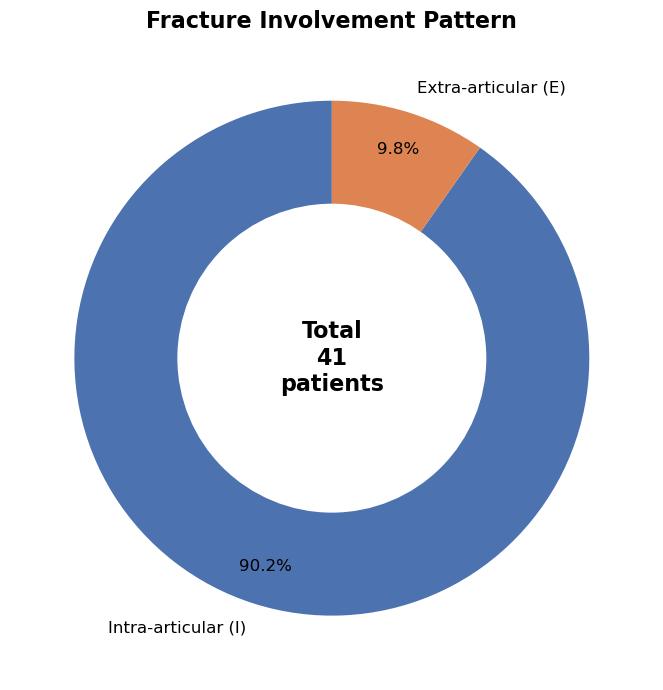

In [103]:
import matplotlib.pyplot as plt

# Data
labels = ['Intra-articular (I)', 'Extra-articular (E)']
sizes = [37, 4]
colors = ['#4C72B0', '#DD8452']  # Medical/aesthetic color scheme

# Create figure
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,  # Pulls % numbers outward for clean donut
    textprops={'fontsize': 12}
)

# Create donut center (white circle)
centre_circle = plt.Circle((0,0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)

# Central annotation (impactful)
plt.text(0, 0, f"Total\n41\npatients",
         ha='center', va='center', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures chart is drawn as a circle
plt.title("Fracture Involvement Pattern", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
